# 02 - E0: MCP's second observation channel

**Question this notebook answers.** Every auditability number this project produced came from `tools/list`. MCP also exposes `resources/*`. Does that channel provide verification the tools channel does not?

**Reads.** `data/processed/resource_sweep.json`

Run top to bottom. Every number below is computed from the raw file named above; nothing is hard-coded.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import nbstyle
from nbstyle import BLUE, ORANGE, AQUA, ORDINAL, INK, INK_2, MUTED, CRITICAL
nbstyle.use_style()
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

def load(name):
    p = PROC / name
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. Raw traces are gitignored; regenerate with the "
            f"command in results/README.md.")
    return json.loads(p.read_text(encoding="utf-8"))

print("reading from", PROC)

reading from F:\UIU\12th\CS\Paper work\repo\data\processed


A resource is addressed by URI. A *static* resource has a fixed address (`config://settings`); a *template* takes a parameter (`file:///{path}`). Only a template can be pointed at the specific record a write just touched, so only a template supports a write-read check.

In [2]:
from collections import Counter
sweep = load("resource_sweep.json")
ok = [r for r in sweep if r.get("status") == "ok"]
print(f"servers probed: {len(sweep)}   answered: {len(ok)}")
chan = Counter(r.get("resource_channel") for r in ok)
for k in ("present", "empty", "unsupported"):
    print(f"  {k:<14} {chan.get(k,0):>5}  {100*chan.get(k,0)/len(ok):>5.1f}%")

n_static = sum(1 for r in ok if r.get("resource_count"))
n_templ  = sum(1 for r in ok if r.get("template_count"))
print(f"\n  publish static resources : {n_static}")
print(f"  publish URI templates    : {n_templ}")

servers probed: 1242   answered: 1216
  present          264   21.7%
  empty            346   28.5%
  unsupported      606   49.8%

  publish static resources : 264
  publish URI templates    : 0


saved results/figures/resource_channel.png


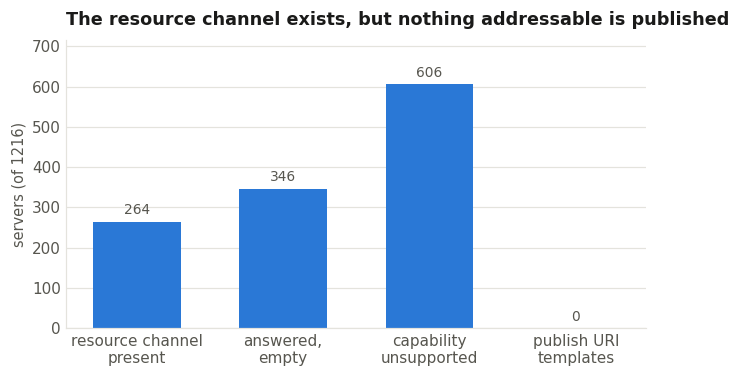

In [3]:
cats = ["resource channel\npresent", "answered,\nempty",
        "capability\nunsupported", "publish URI\ntemplates"]
vals = [chan.get("present",0), chan.get("empty",0),
        chan.get("unsupported",0), n_templ]
# One series. The final bar is the finding, so it carries the status
# colour -- reserved, and used here for state, not as a fourth category.
colors = [BLUE, BLUE, BLUE, CRITICAL]

fig, ax = plt.subplots(figsize=(6.8, 3.4))
bars = ax.bar(cats, vals, color=colors, width=0.6)
nbstyle.bar_labels(ax, bars)
ax.set_ylabel(f"servers (of {len(ok)})")
ax.set_title("The resource channel exists, but nothing addressable is published")
ax.set_ylim(0, max(vals)*1.18)
nbstyle.save(fig, "resource_channel", RESULTS); plt.show()

## Upper bound on the correction to A0

In [4]:
READ = {"get","list","read","search","fetch","query","find","show",
        "describe","view","lookup","retrieve"}
def has_read_tool(r):
    for t in r.get("tools", []):
        if t.get("readOnlyHint") is True: return True
        if t["name"].replace("-","_").split("_")[0].lower() in READ: return True
    return False

no_read   = [r for r in ok if not has_read_tool(r)]
recovered = [r for r in no_read if r.get("resource_channel") == "present"]
print(f"servers with no read-shaped tool at all : {len(no_read)}")
print(f"  ...of those, exposing any resources   : {len(recovered)}"
      f"  ({100*len(recovered)/max(len(no_read),1):.1f}%)")
print("\nUpper bound only: having a resource channel does not mean the")
print("channel observes what the write changed. And a resource read is as")
print("forgeable as a tool response -- this widens observation, not trust.")

servers with no read-shaped tool at all : 143
  ...of those, exposing any resources   : 26  (18.2%)

Upper bound only: having a resource channel does not mean the
channel observes what the write changed. And a resource read is as
forgeable as a tool response -- this widens observation, not trust.
